# Source A × the IRS — what a county's Wikipedia article knows about its wages

Source A is the Wikipedia-county-articles pillar of `E_macro`. Everything it
has been scored against until now came from the Census. This scores it against
the **IRS** instead — average wage and salary income per return, from the
Statistics of Income county file — which shares no collection instrument with
the ACS. Counties are split into the four content tiers defined by article
length: **stub**, **thin**, **mid**, **rich**.

**Two targets, two different answers.**

| | wage **level** | wage **growth**, 2018→2022 |
|---|---|---|
| tier gradient | strong, but mostly county size | none |
| block predicts out-of-fold? | **yes**, and it survives lat/lon | **no** |
| individual columns? | article length, metro attachment | **oil & gas ↓, tourism ↑** |

And a third question, in §3: **how much can you read off an article without
reading it** — section counts, section lengths, which titles exist, what order
they come in? 137 such columns. The answer is a short one, and the reason is
about Wikipedia's editors rather than about counties.

Full method, controls and caveats: `scripts/analyze_source_a_wage.py`.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
SOURCE_A, OUTPUTS = REPO / "analysis-output" / "source-a", REPO / "outputs"

mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "axes.axisbelow": True,
                     "grid.alpha": 0.22, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 11,
                     "axes.titlecolor": "#333333"})

BLUE, DEEP, MUTED, HOT, INK = "#7a9cc6", "#2f5d8a", "#c3ccd6", "#c1440e", "#333333"

stats = json.loads((SOURCE_A / "source_a_wage_stats.json").read_text())
tiers = pd.read_csv(OUTPUTS / "source_a_wage_by_tier.csv", index_col=0)
effects = pd.read_csv(OUTPUTS / "source_a_wage_feature_effects.csv",
                      float_precision="round_trip")

LEVEL, GROWTH = stats["level_target"], stats["growth_target"]
TIERS = [t for t in stats["tier_labels"] if t in tiers.index]
START_YEAR, END_YEAR = stats["growth_years"]
SCORES = stats["scores"]


def annotate(ax, xs, values, fmt, size=9, dy=0.03, rotation=0):
    """Print each bar's value just outside its end."""
    span = max(abs(v) for v in values) or 1.0
    for x, v in zip(xs, values):
        ax.text(x, v + (dy * span if v >= 0 else -dy * span), fmt.format(v),
                ha="center", va="bottom" if v >= 0 else "top",
                fontsize=size, rotation=rotation)


def tier_ticks():
    """Tier names with their county counts, for x-axis labels."""
    return [f"{t}\n{int(tiers.loc[t, 'n_counties']):,}" for t in TIERS]


print(f"{stats['n_counties']:,} counties matched: Wikipedia article × IRS return file "
      f"({stats['n_counties_growth']:,} also observed in both {START_YEAR} and {END_YEAR})")

3,143 counties matched: Wikipedia article × IRS return file (3,132 also observed in both 2018 and 2022)


---

## 1. The wage gradient is real, and it is mostly population

Longer articles describe bigger places, and bigger places pay more. The left
panel is the raw gradient; the right panel is the same gap re-measured with
`log_population` in the model. **About a third of it survives** — so among
counties of the same size, the ones with more written about them do pay more,
but the raw chart overstates it threefold.

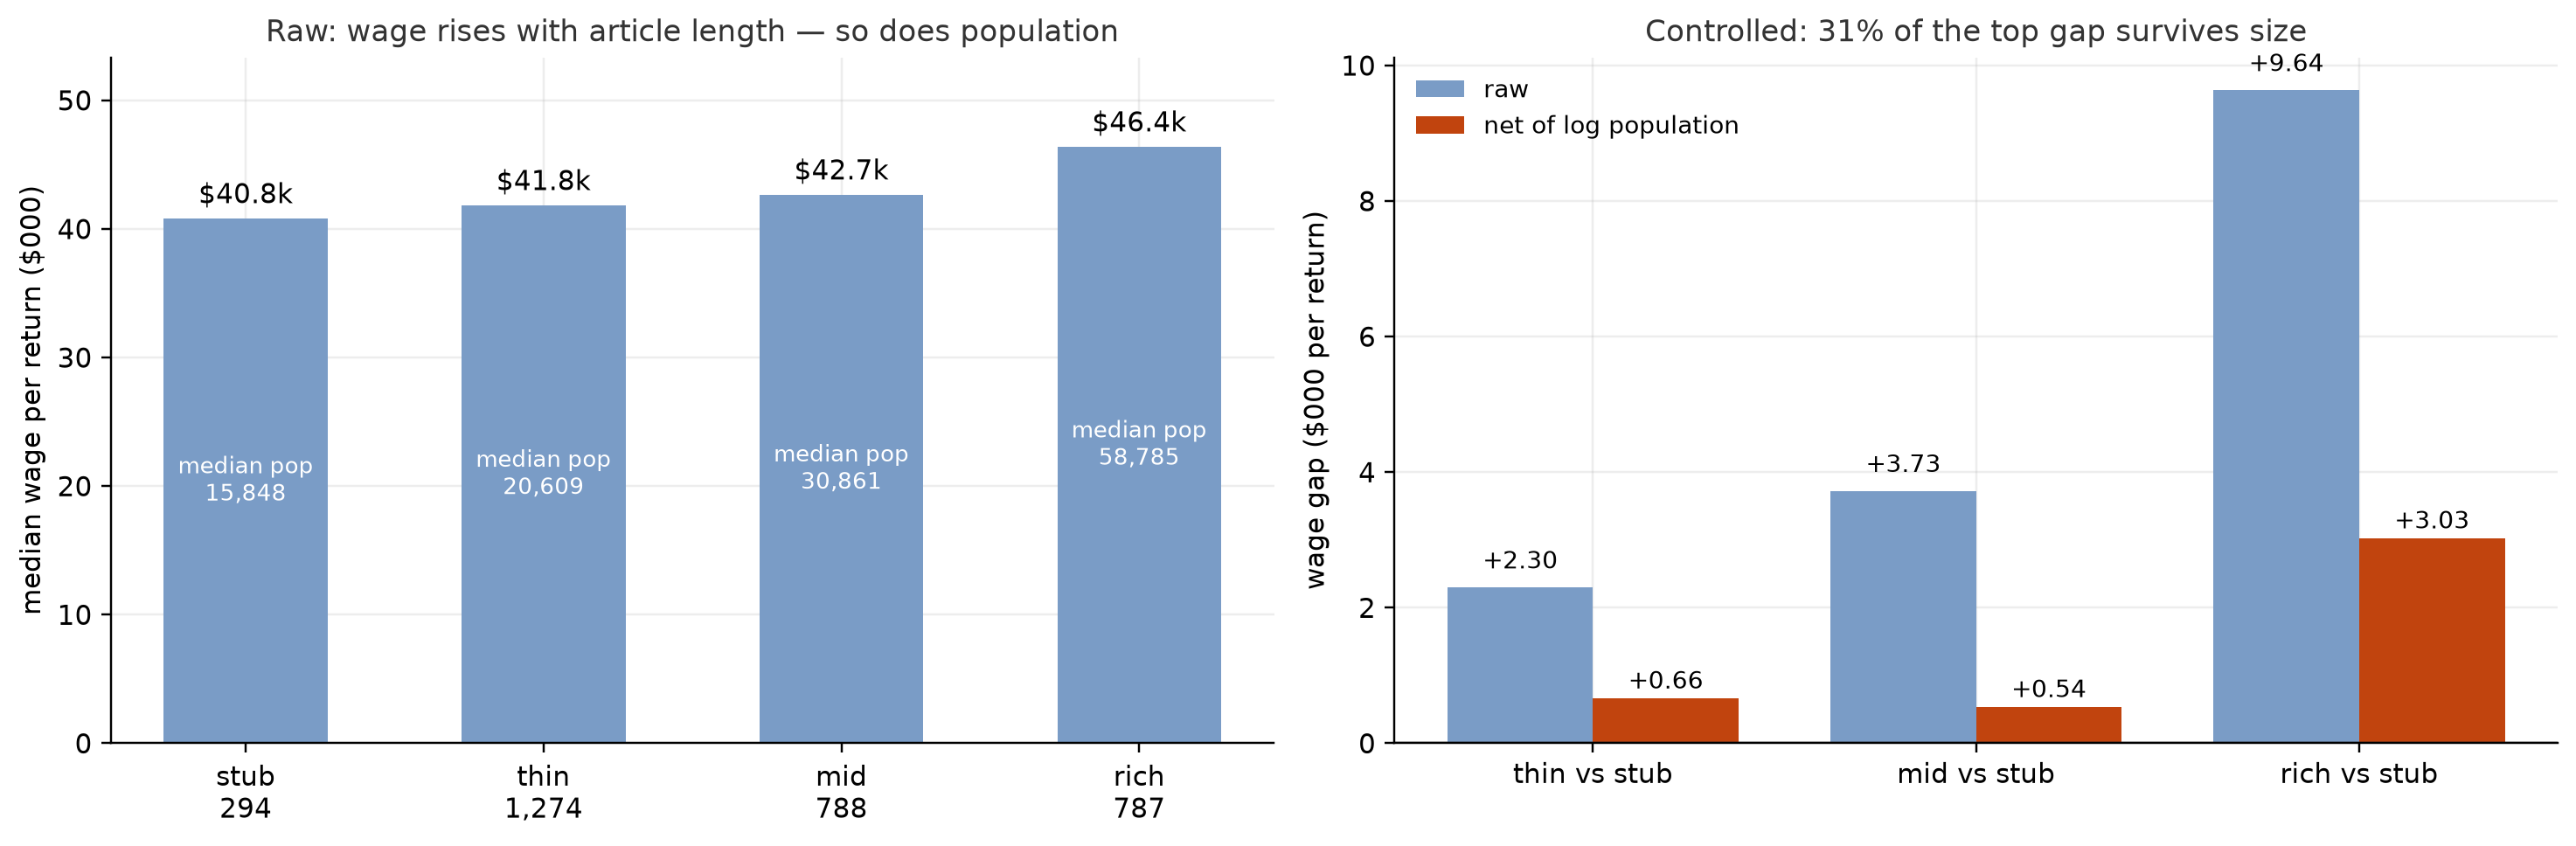

In [2]:
gradient = stats["tier_gradient"][LEVEL]
raw, ctrl = gradient["raw_coefficients"], gradient["size_controlled_coefficients"]
levels = [t for t in TIERS if t in raw]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))

x = np.arange(len(TIERS))
medians = [tiers.loc[t, "median_wage"] for t in TIERS]
pops = [tiers.loc[t, "median_population"] for t in TIERS]
axes[0].bar(x, medians, 0.55, color=BLUE)
annotate(axes[0], x, medians, "${:,.1f}k", size=10, dy=0.015)
for xi, (m, p) in enumerate(zip(medians, pops)):
    axes[0].text(xi, m / 2, f"median pop\n{int(p):,}", ha="center", va="center",
                 fontsize=8.5, color="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_ticks())
axes[0].set_ylim(0, max(medians) * 1.15)
axes[0].set_ylabel("median wage per return ($000)")
axes[0].set_title("Raw: wage rises with article length — so does population")

y = np.arange(len(levels)); w = 0.38
axes[1].bar(y - w / 2, [raw[t] for t in levels], w, color=BLUE, label="raw")
axes[1].bar(y + w / 2, [ctrl[t] for t in levels], w, color=HOT,
            label="net of log population")
annotate(axes[1], y - w / 2, [raw[t] for t in levels], "{:+.2f}", dy=0.02)
annotate(axes[1], y + w / 2, [ctrl[t] for t in levels], "{:+.2f}", dy=0.02)
axes[1].axhline(0, color=INK, lw=0.8)
axes[1].set_xticks(y)
axes[1].set_xticklabels([f"{t} vs {gradient['reference_tier']}" for t in levels])
axes[1].set_ylabel("wage gap ($000 per return)")
axes[1].set_title(f"Controlled: {gradient['share_of_top_gap_surviving_size']:.0%} "
                  f"of the top gap survives size")
axes[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Does it actually predict? Yes — even knowing where the county is

The test: build a model that already knows something about a county, then hand
it Source A's 29 columns and see whether the predictions get better. The bar is
how much better. Predictions are made for counties in states the model never
trained on, so it cannot succeed by memorising a state.

Three things to already know, left to right:

- **Population.** The fair starting point, since Part 1 showed size drives most
  of the raw gradient.
- **Population and where the county is** (its latitude and longitude). These
  two numbers are what wiped out Source A's value in every previous round. Here
  they do not — the bar gets slightly *bigger*.
- **Population, income and economic output.** The grey bar. This one is a trap:
  total income divided by population is roughly average income per person,
  which is almost the thing being predicted. Anything Source A adds on top of
  that is bound to look tiny. Shown so nobody has to ask, not as a real test.

Whiskers show how much each bar would move if the counties were resampled.

The right panel is the same model, scored separately within each tier. Source A
helps where there is something written to read, and **hurts** in the stub tier,
where nearly all of its columns are empty.

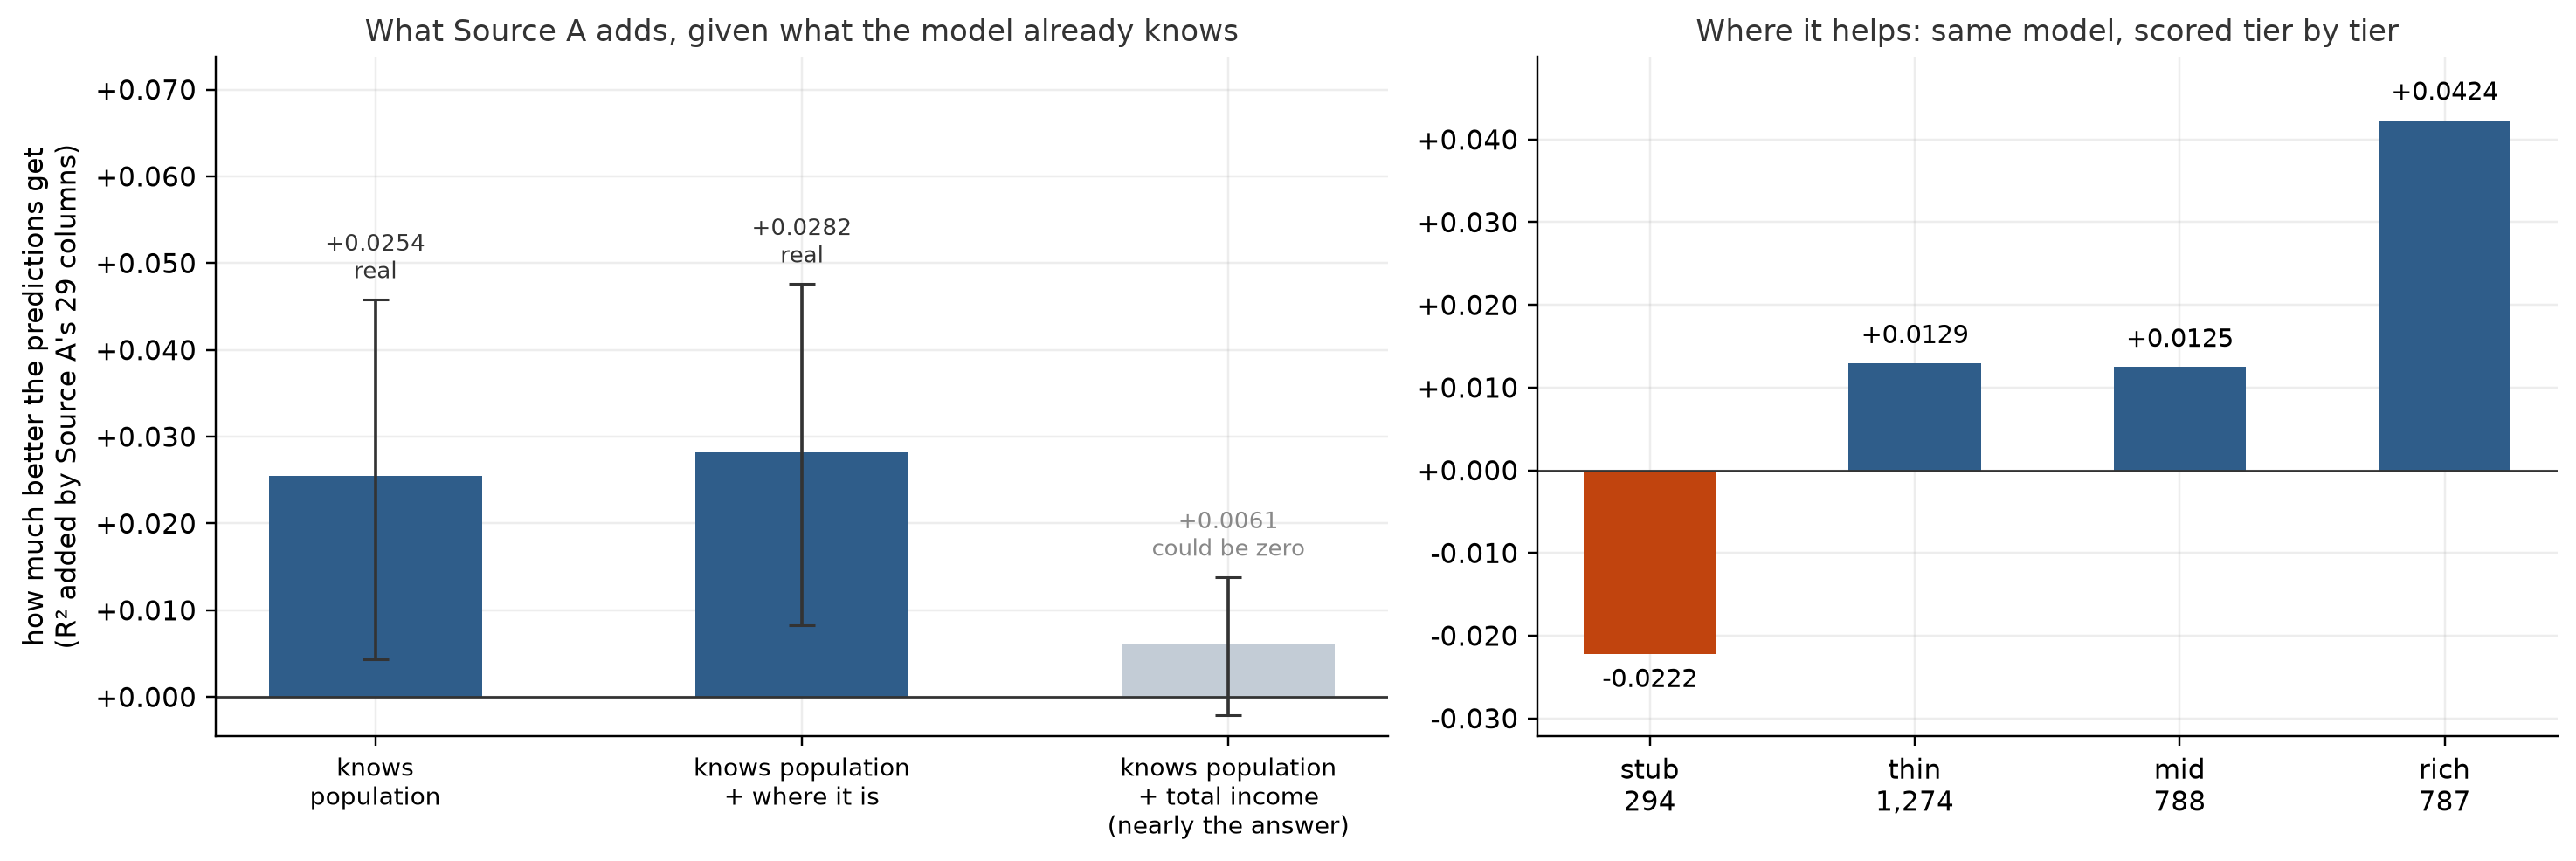

In [3]:
entries = SCORES[LEVEL]["by_baseline"]
names = list(entries)
LABEL = {"headcount": "knows\npopulation",
         "geo": "knows population\n+ where it is",
         "size_full": "knows population\n+ total income\n(nearly the answer)"}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6),
                         gridspec_kw={"width_ratios": [1.15, 1]})

x = np.arange(len(names))
points = [entries[n]["contribution"] for n in names]
err = [[p - entries[n]["bootstrap"]["low"] for p, n in zip(points, names)],
       [entries[n]["bootstrap"]["high"] - p for p, n in zip(points, names)]]
clears = [entries[n]["bootstrap"]["low"] > 0 for n in names]
axes[0].bar(x, points, 0.5, color=[DEEP if c else MUTED for c in clears])
axes[0].errorbar(x, points, yerr=err, fmt="none", ecolor=INK, capsize=5, lw=1.2)
axes[0].axhline(0, color=INK, lw=0.9)
axes[0].set_xticks(x); axes[0].set_xticklabels([LABEL[n] for n in names], fontsize=9)
for xi, (p, n, c) in enumerate(zip(points, names, clears)):
    axes[0].text(xi, entries[n]["bootstrap"]["high"] + 0.0025,
                 f"{p:+.4f}\n{'real' if c else 'could be zero'}",
                 ha="center", fontsize=8.5, color=INK if c else "#888888")
axes[0].set_ylim(top=max(entries[n]["bootstrap"]["high"] for n in names) * 1.55)
axes[0].set_ylabel("how much better the predictions get\n(R² added by Source A's 29 columns)")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
axes[0].set_title("What Source A adds, given what the model already knows")

by_tier = entries["headcount"]["by_tier"]
order = [t for t in TIERS if t in by_tier]
values = [by_tier[t]["contribution"] for t in order]
axes[1].bar(np.arange(len(order)), values, 0.5,
            color=[DEEP if v > 0 else HOT for v in values])
annotate(axes[1], np.arange(len(order)), values, "{:+.4f}", size=9.5, dy=0.04)
axes[1].axhline(0, color=INK, lw=0.9)
# Headroom at both ends so the labels on the negative bar clear the tick text.
axes[1].set_ylim(min(values) * 1.45, max(values) * 1.18)
axes[1].set_xticks(np.arange(len(order)))
axes[1].set_xticklabels([f"{t}\n{by_tier[t]['n_counties']:,}" for t in order])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
axes[1].set_title("Where it helps: same model, scored tier by tier")
plt.tight_layout(); plt.show()

## 3. How far does the *dumb* stuff get you?

Everything above uses the 29-column lexicon block, which parses words. This
part asks what you can read off a Wikipedia article **without reading it at
all** — how long it is, how many sections it has, how long those sections are,
which titles are present, what order they come in, even how many digits they
contain. 137 such columns exist across two parquets.

Each block is scored the same way: R² added over a model already holding
`log_population`. The grey ticks are each block's **width-matched noise floor** —
what the same number of pure-Gaussian columns scores through the identical
path. A block that does not beat its own tick has not been shown to carry
anything.

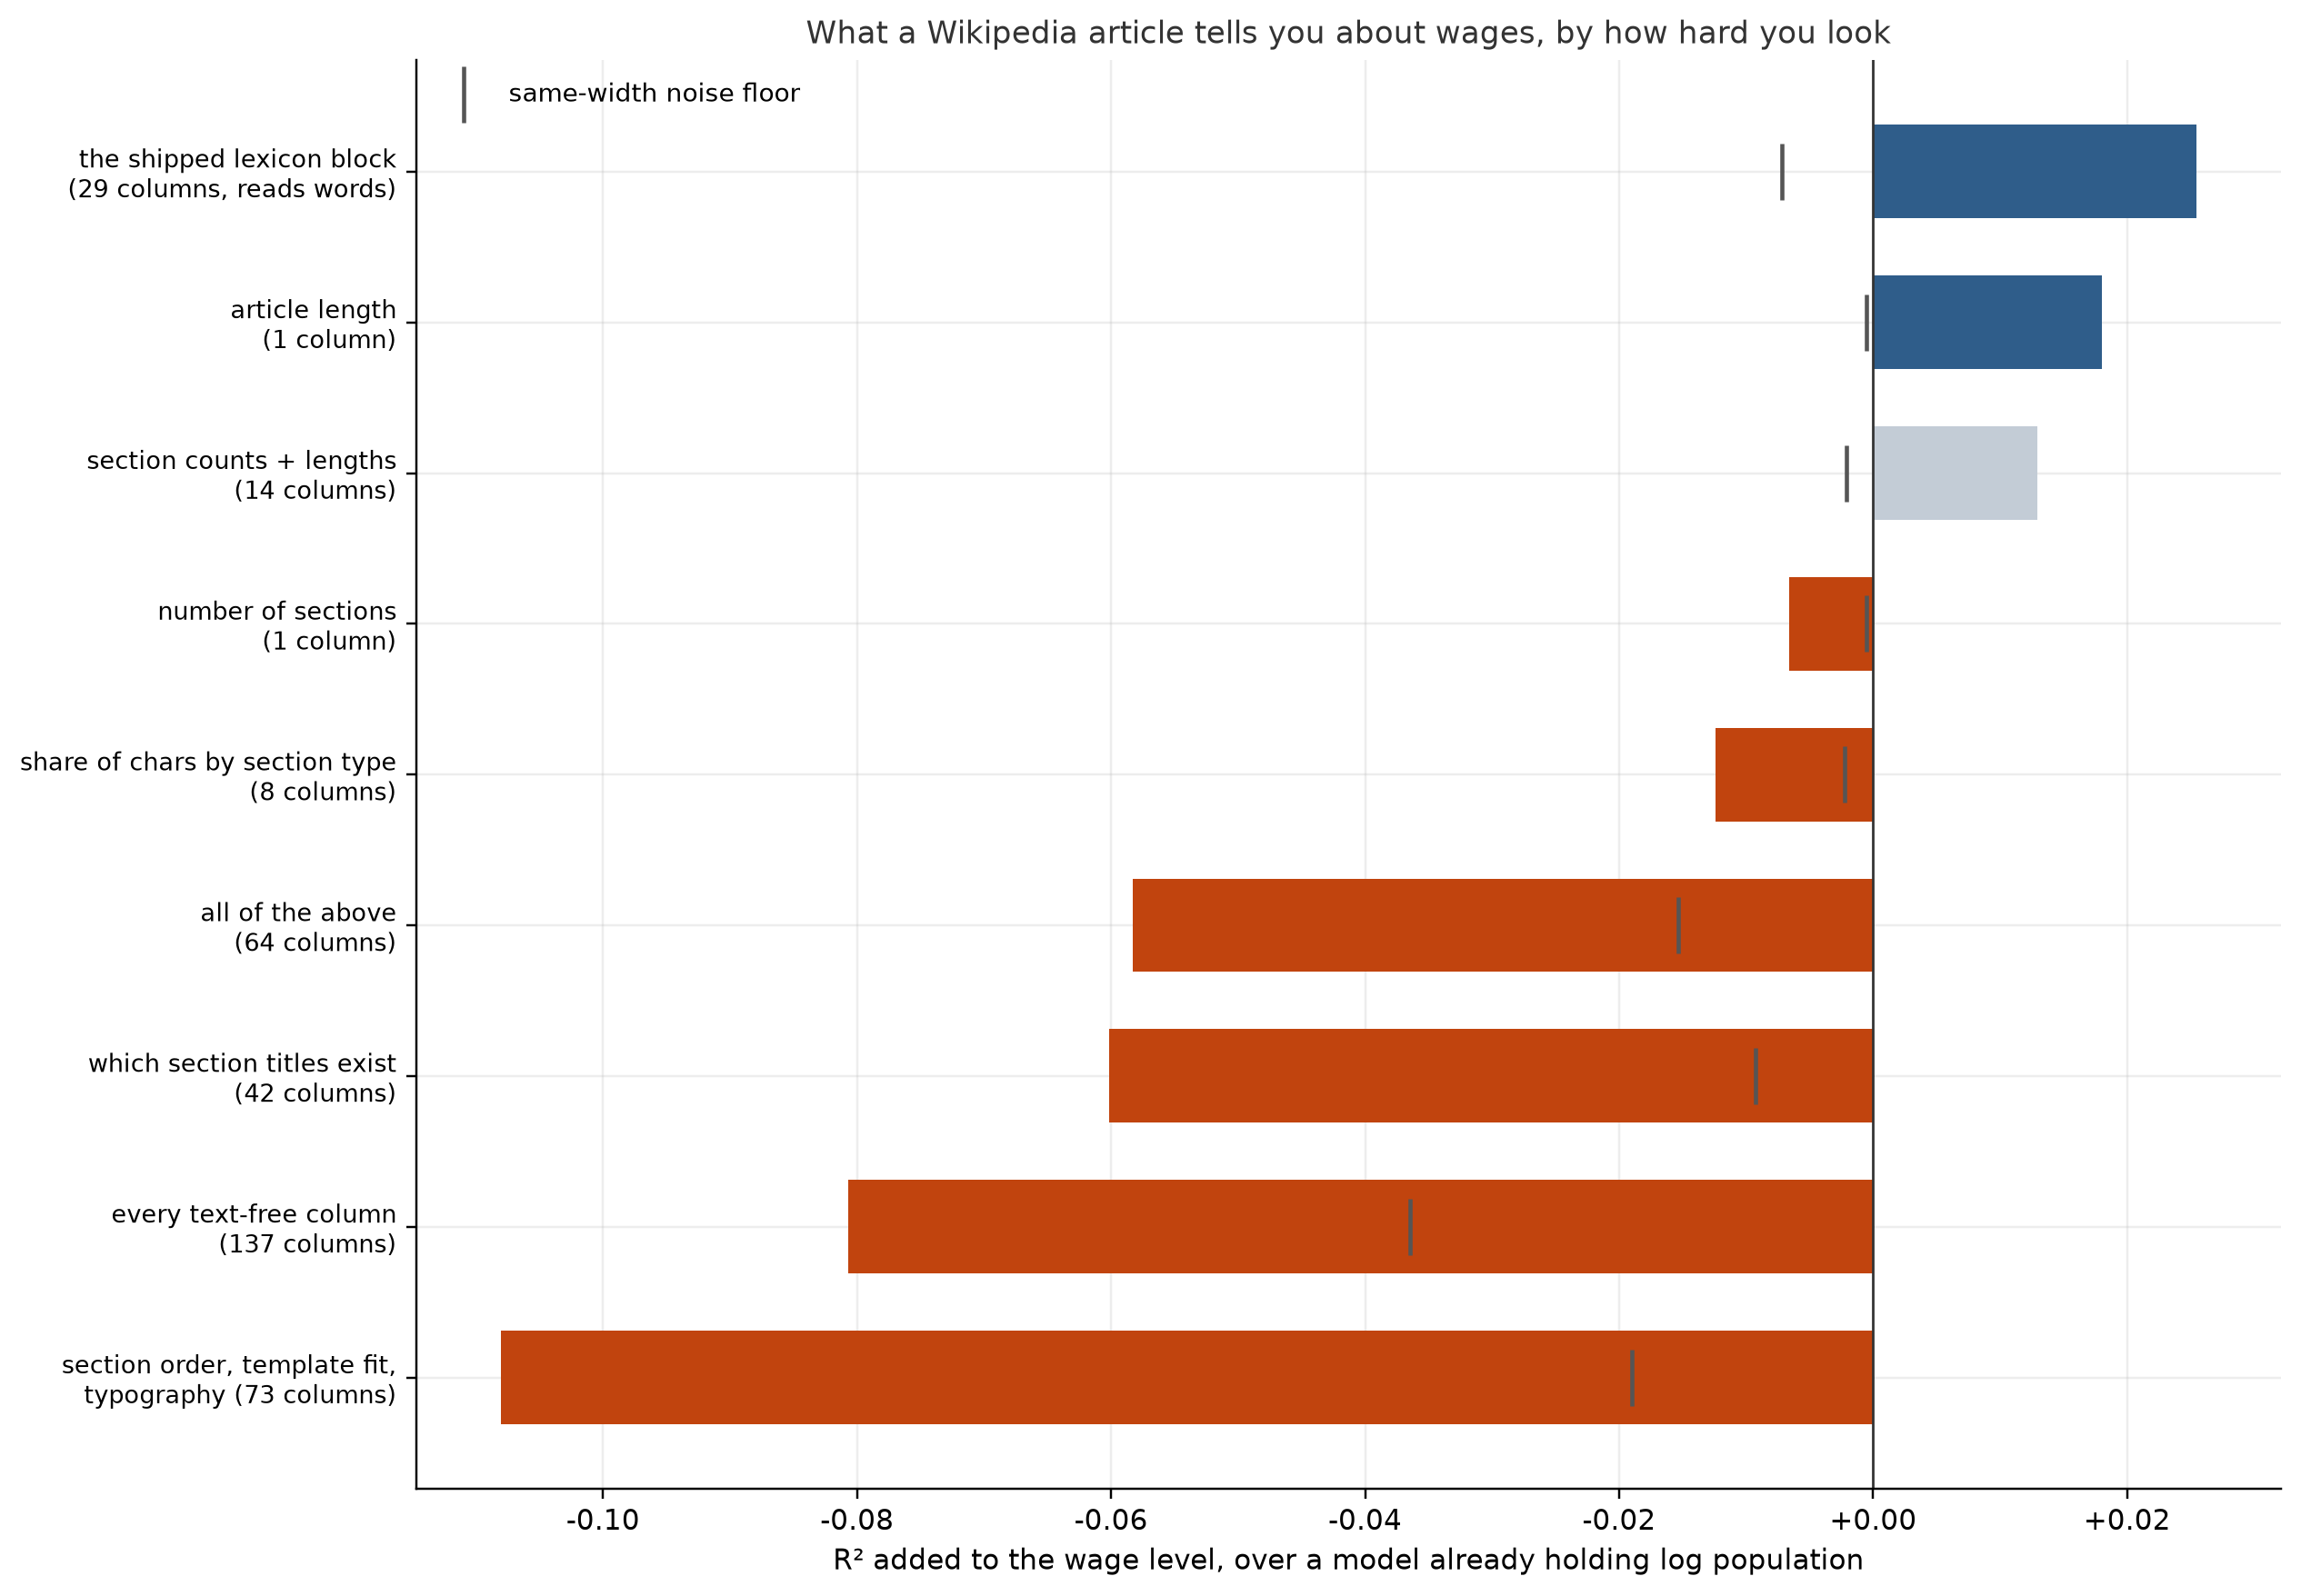

In [4]:
blocks = pd.read_csv(OUTPUTS / "source_a_wage_block_scores.csv",
                     float_precision="round_trip")
BLOCK_LABEL = {
    "length_only": "article length\n(1 column)",
    "sections_only": "number of sections\n(1 column)",
    "counts_and_lengths": "section counts + lengths\n(14 columns)",
    "section_mix": "share of chars by section type\n(8 columns)",
    "which_sections": "which section titles exist\n(42 columns)",
    "structure": "all of the above\n(64 columns)",
    "shape_profile": "section order, template fit,\ntypography (73 columns)",
    "everything_dumb": "every text-free column\n(137 columns)",
    "typed_lexicon": "the shipped lexicon block\n(29 columns, reads words)",
}

view = (blocks[(blocks["target"] == LEVEL) & (blocks["baseline"] == "headcount")]
        .set_index("block").loc[list(BLOCK_LABEL)])
order = view["contribution"].sort_values().index

y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(11.5, 0.72 * len(order) + 1.6))
colours = [DEEP if view.loc[b, "clears_zero"] else
           (MUTED if view.loc[b, "contribution"] > view.loc[b, "noise_floor"] else HOT)
           for b in order]
ax.barh(y, [view.loc[b, "contribution"] for b in order], 0.62, color=colours)
ax.scatter([view.loc[b, "noise_floor"] for b in order], y, marker="|", s=420,
           color="#555555", zorder=5, label="same-width noise floor")
ax.axvline(0, color=INK, lw=0.9)
ax.set_yticks(y)
ax.set_yticklabels([BLOCK_LABEL[b] for b in order], fontsize=8.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.set_xlabel("R² added to the wage level, over a model already holding log population")
ax.set_title("What a Wikipedia article tells you about wages, by how hard you look")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

**Article length — one number — is the only text-free thing that works.** It
clears zero. Everything more elaborate is *worse than nothing*, and worse than
same-width noise: the 73-column shape profile lands far below the floor its own
width scores, so this is not the ridge merely paying for columns.

That needs an explanation, and the next figure is it.

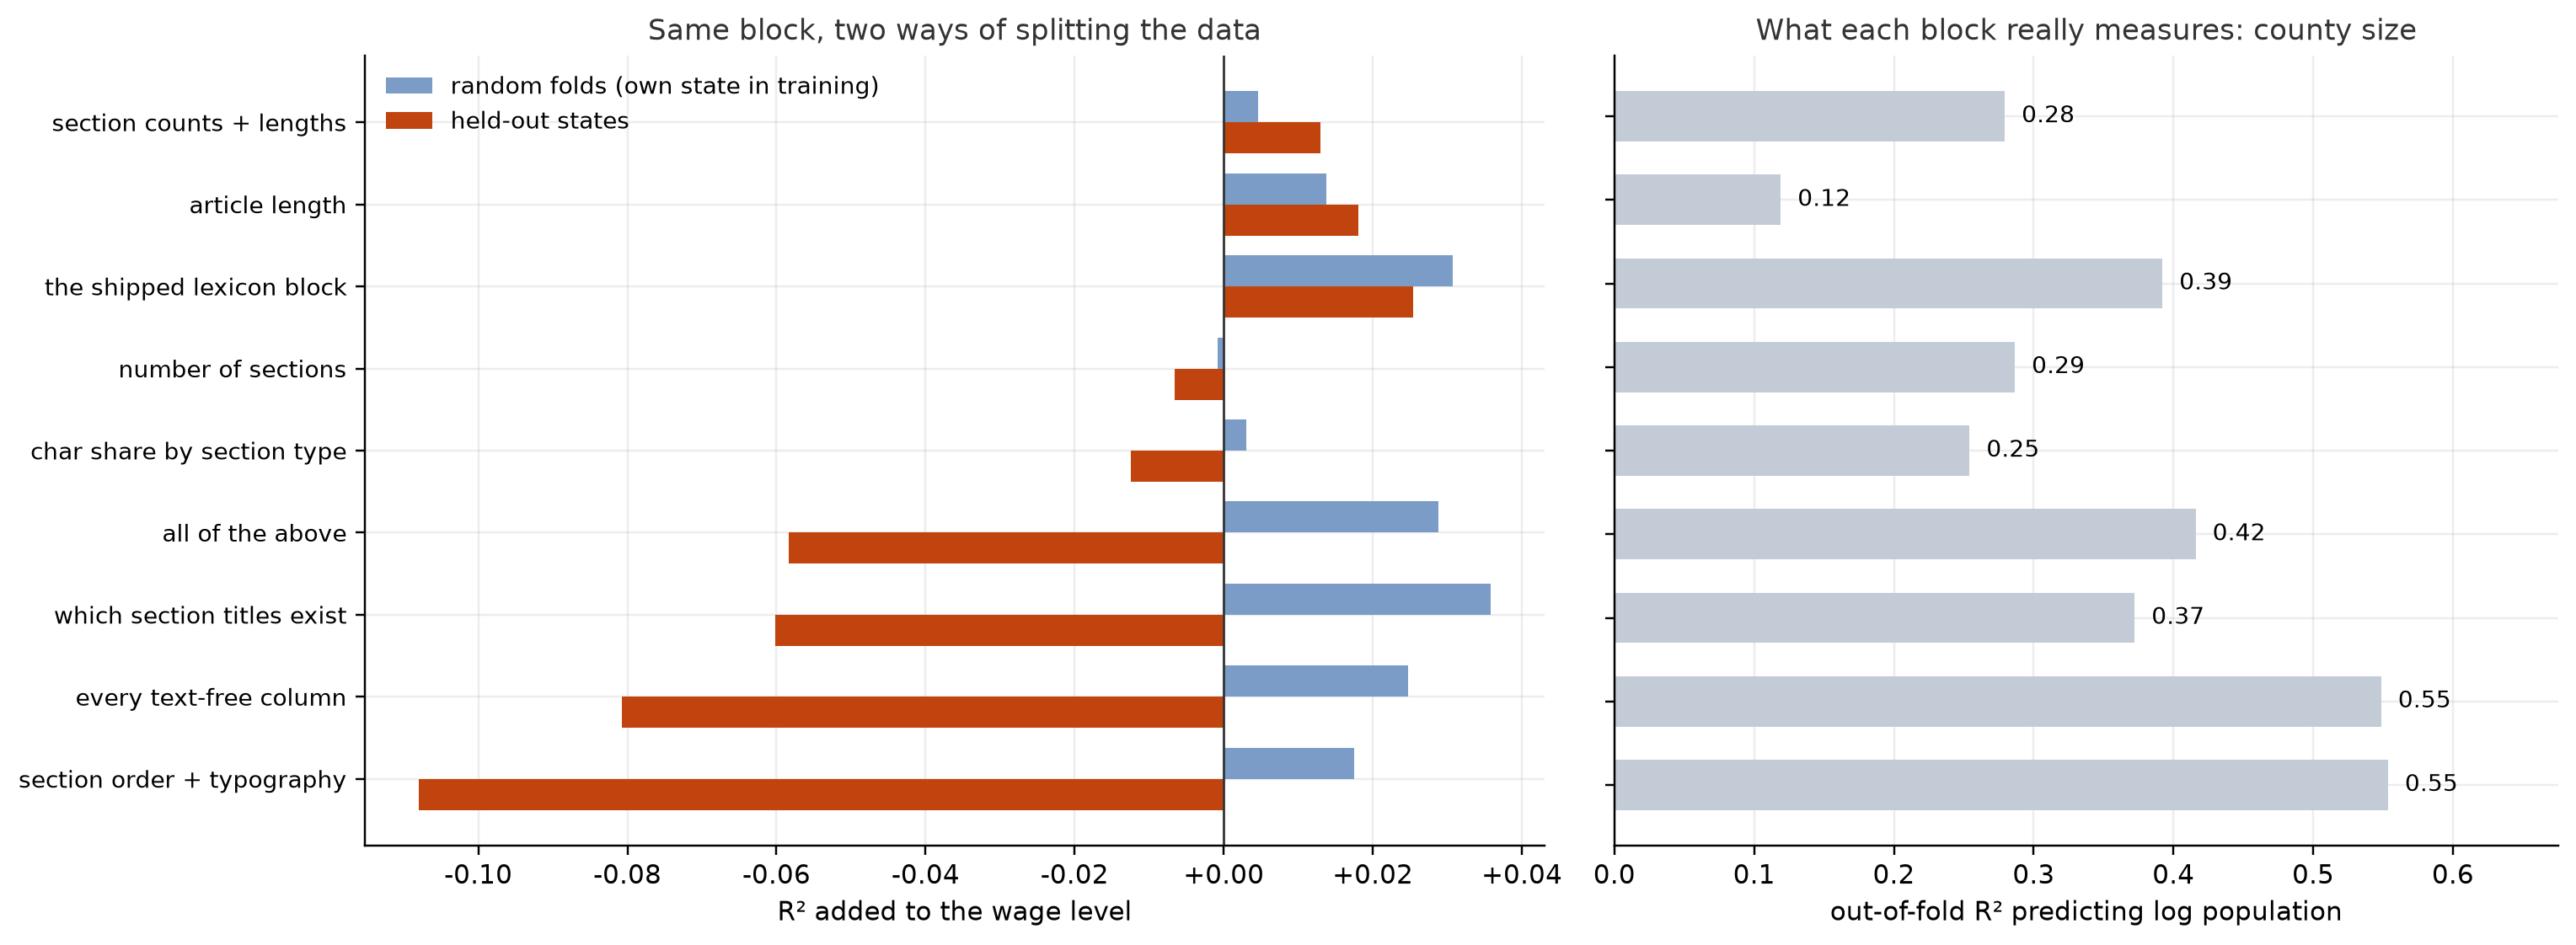

In [5]:
transfer = stats["blocks"]["cv_transfer"][LEVEL]
recovery = stats["blocks"]["size_recoverability"]
keys = sorted(BLOCK_LABEL, key=lambda b: transfer[b]["transfer_gap"])
SHORT = {"length_only": "article length", "sections_only": "number of sections",
         "counts_and_lengths": "section counts + lengths",
         "section_mix": "char share by section type",
         "which_sections": "which section titles exist",
         "structure": "all of the above",
         "shape_profile": "section order + typography",
         "everything_dumb": "every text-free column",
         "typed_lexicon": "the shipped lexicon block"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2),
                         gridspec_kw={"width_ratios": [1.25, 1]})

y = np.arange(len(keys)); h = 0.38
axes[0].barh(y + h / 2, [transfer[b]["random_folds"] for b in keys], h,
             color=BLUE, label="random folds (own state in training)")
axes[0].barh(y - h / 2, [transfer[b]["grouped_by_state"] for b in keys], h,
             color=HOT, label="held-out states")
axes[0].axvline(0, color=INK, lw=0.9)
axes[0].set_yticks(y); axes[0].set_yticklabels([SHORT[b] for b in keys], fontsize=9)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.2f}"))
axes[0].set_xlabel("R² added to the wage level")
axes[0].set_title("Same block, two ways of splitting the data")
axes[0].legend(frameon=False, fontsize=9, loc="upper left")

rec = [recovery[b] for b in keys]
axes[1].barh(y, rec, 0.6, color=MUTED)
for yi, v in zip(y, rec):
    axes[1].text(v + 0.012, yi, f"{v:.2f}", va="center", fontsize=9)
axes[1].set_yticks(y); axes[1].set_yticklabels([])
axes[1].set_xlim(0, max(rec) * 1.22)
axes[1].set_xlabel("out-of-fold R² predicting log population")
axes[1].set_title("What each block really measures: county size")
plt.tight_layout(); plt.show()

**It is not a fact about counties. It is a fact about editors.**

Which sections a county article has is mostly decided by whoever templated that
state's counties for WikiProject — "Townships" across the Midwest, "Parishes"
in Louisiana, "Census-designated places" where those exist. So section
inventory genuinely predicts wages **within** a state, and the relationship
does not survive being asked about a state the model has never seen. Left
panel: the wide blocks flip sign between the two protocols. Article length and
the lexicon block barely move — they describe the county, not the editor.

The right panel is the second half of it. These blocks reconstruct county
**population** from nothing but section positions and digit counts, better than
the lexicon block does. They are population sensors. Once population is already
in the baseline, what is left is a state-calibrated artifact, which is why
adding them makes the model actively worse.

**The practical read:** for a text-free signal, take `content_length` and stop.
The 136 columns after it cost accuracy.

## 4. Which columns carry the level

Partial effect of each Source A column on wage per return, holding county
population — and then also holding **state**. Only columns clearing a
Benjamini-Hochberg correction over all 29 are shown.

Effects are **per one standard deviation of the column**, because Source A
mixes 0/1 flags with a character count: in natural units `content_length`'s
effect is dollars-per-character and would not be visible beside a flag.

Watch the two bars per row. `has_metro_attachment` **grows** inside a state —
the editorial fact that a county belongs to a metro area is worth more than the
national comparison showed. `content_length` **shrinks**: part of what article
length was carrying is that verbose-article counties sit in better-paid states.

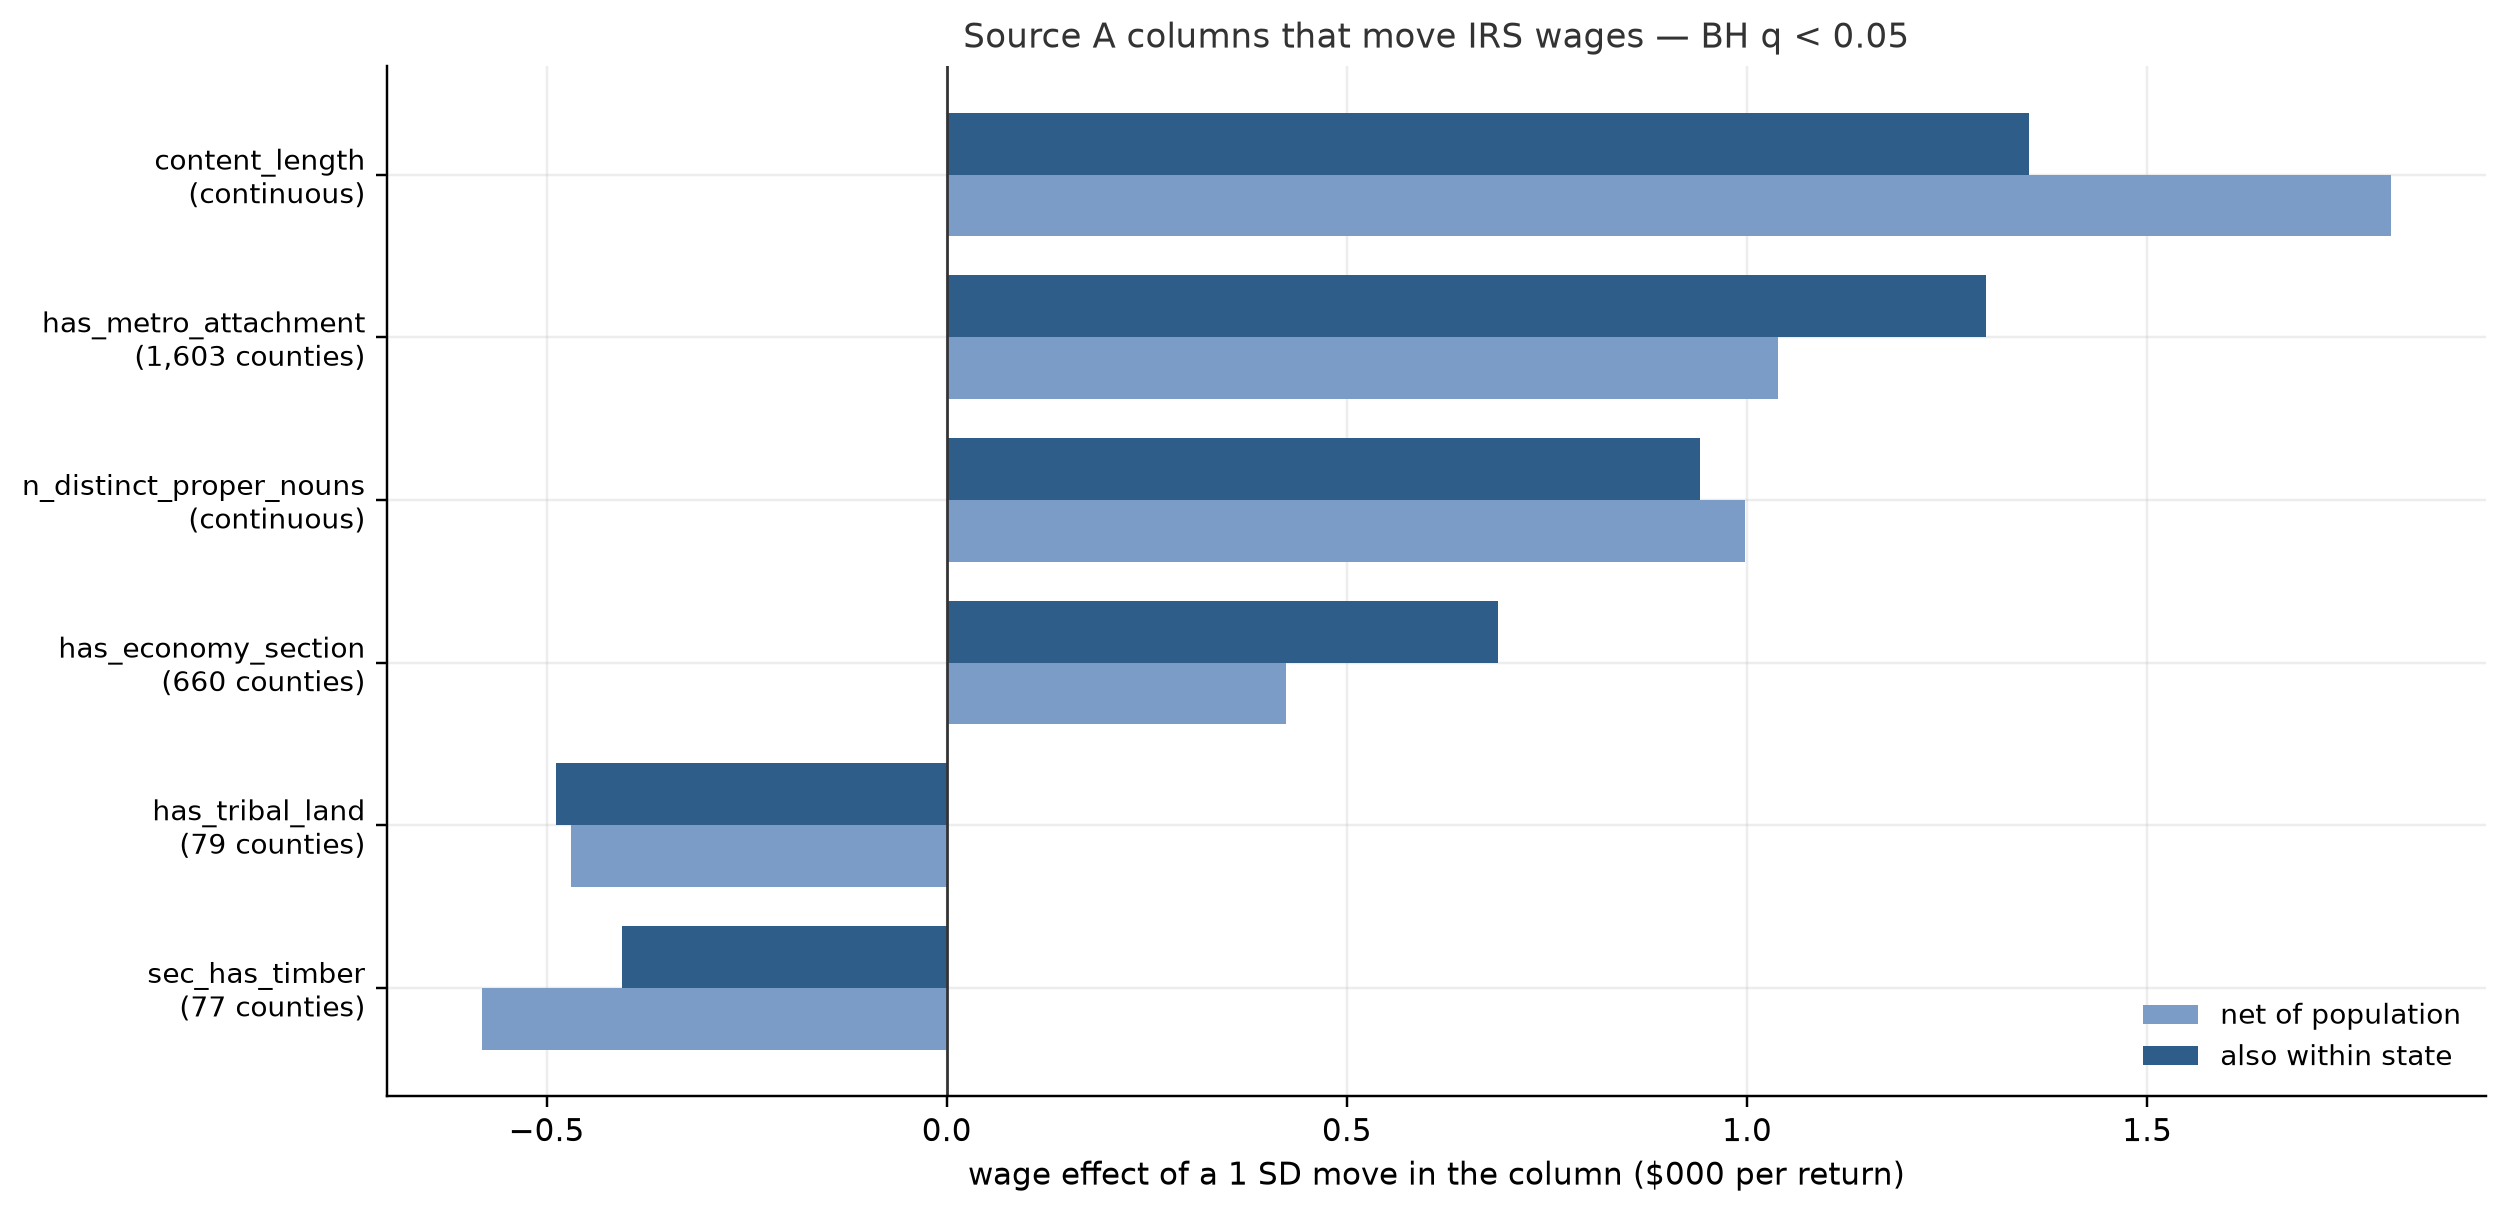

In [6]:
def called_columns(target):
    """Columns clearing BH under either control set, with both effect sizes."""
    frame = effects[effects["target"] == target]
    wide = frame.pivot(index="column", columns="control_set",
                       values=["effect_per_sd", "significant", "n_true"])
    keep = [c for c in wide.index
            if wide["significant"]["size"][c] or wide["significant"]["size_state"][c]]
    return wide, sorted(keep, key=lambda c: wide["effect_per_sd"]["size"][c])


def effect_chart(target, xlabel, title, formatter=None):
    """Paired per-SD effect bars, one row per column clearing BH."""
    wide, keep = called_columns(target)
    y = np.arange(len(keep)); h = 0.38
    fig, ax = plt.subplots(figsize=(11.5, 0.62 * len(keep) + 1.9))
    for offset, scheme, colour, label in (
        (-h / 2, "size", BLUE, xlabel[0]), (h / 2, "size_state", DEEP, xlabel[1])
    ):
        values = [wide["effect_per_sd"][scheme][c] for c in keep]
        ax.barh(y + offset, values, h, color=colour, label=label)
    ax.axvline(0, color=INK, lw=0.9)
    ax.set_yticks(y)
    ax.set_yticklabels(
        [f"{c}\n({int(wide['n_true']['size'][c]):,} counties)"
         if pd.notna(wide["n_true"]["size"][c]) else f"{c}\n(continuous)"
         for c in keep], fontsize=9)
    if formatter is not None:
        ax.xaxis.set_major_formatter(FuncFormatter(formatter))
    ax.set_xlabel(xlabel[2])
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    plt.tight_layout(); plt.show()


effect_chart(
    LEVEL,
    ("net of population", "also within state",
     "wage effect of a 1 SD move in the column ($000 per return)"),
    f"Source A columns that move IRS wages — BH q < {stats['q_threshold']}",
)

---

## 5. Now the change — and here the tiers say nothing

Wage growth over the IRS panel is **flat across the tiers** (left), so there is
no size confound to strip out. The block does not predict it out-of-fold either
— both usable baselines straddle zero (right).

That is the honest headline for the block. The next figure is why it is not the
whole story.

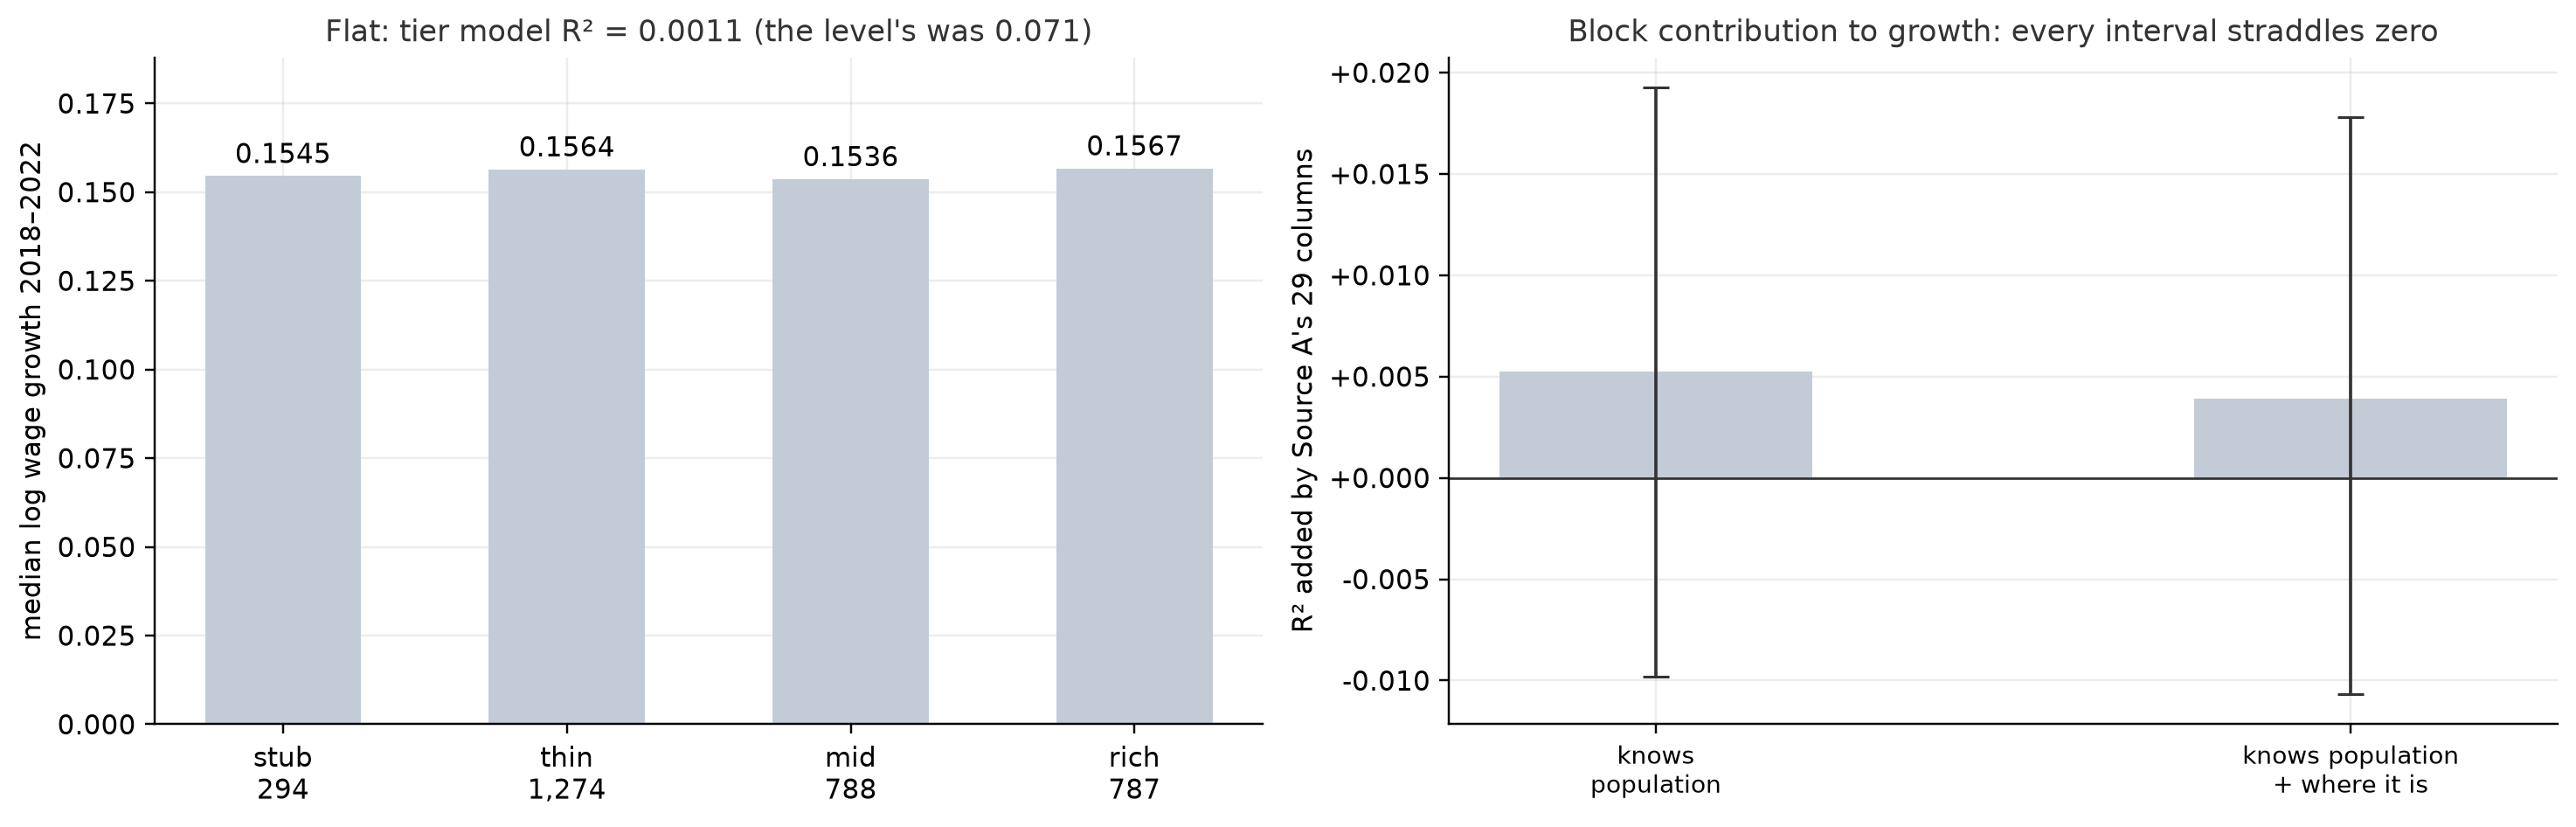

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

x = np.arange(len(TIERS))
growth = [tiers.loc[t, "median_growth"] for t in TIERS]
axes[0].bar(x, growth, 0.55, color=MUTED)
annotate(axes[0], x, growth, "{:.4f}", size=10, dy=0.012)
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_ticks())
axes[0].set_ylim(0, max(growth) * 1.2)
axes[0].set_ylabel(f"median log wage growth {START_YEAR}–{END_YEAR}")
axes[0].set_title(f"Flat: tier model R² = "
                  f"{stats['tier_gradient'][GROWTH]['raw_r2']:.4f} "
                  f"(the level's was {stats['tier_gradient'][LEVEL]['raw_r2']:.3f})")

g = SCORES[GROWTH]["by_baseline"]
usable = [n for n in g if n != "size_full"]
gx = np.arange(len(usable))
gp = [g[n]["contribution"] for n in usable]
gerr = [[p - g[n]["bootstrap"]["low"] for p, n in zip(gp, usable)],
        [g[n]["bootstrap"]["high"] - p for p, n in zip(gp, usable)]]
axes[1].bar(gx, gp, 0.45, color=MUTED)
axes[1].errorbar(gx, gp, yerr=gerr, fmt="none", ecolor=INK, capsize=5, lw=1.2)
axes[1].axhline(0, color=INK, lw=0.9)
axes[1].set_xticks(gx); axes[1].set_xticklabels([LABEL[n] for n in usable], fontsize=9)
axes[1].set_ylabel("R² added by Source A's 29 columns")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:+.3f}"))
axes[1].set_title("Block contribution to growth: every interval straddles zero")
plt.tight_layout(); plt.show()

## 6. The columns, though, read like economics

Same chart as §4, on growth. Controls: population, the **starting wage level**
(so this is not mean reversion), and state. BH over all 29 columns.

**This is the sign pattern a macro analyst would write down for 2018–2022
without any of this data.** Energy counties took the 2020 price collapse and had
not made it back; tourism and recreation counties came out with visibly stronger
wage growth. It survives state fixed effects, so it is not simply Texas and
North Dakota. And the section-derived flag beats the lead-derived one — the
economic content of a county article mostly sits below the lead.

**Why the block still scored zero.** Three working columns averaged against
twenty-six carrying nothing, under a ridge penalty wide enough to shrink all
twenty-nine. A block score is not a column score.

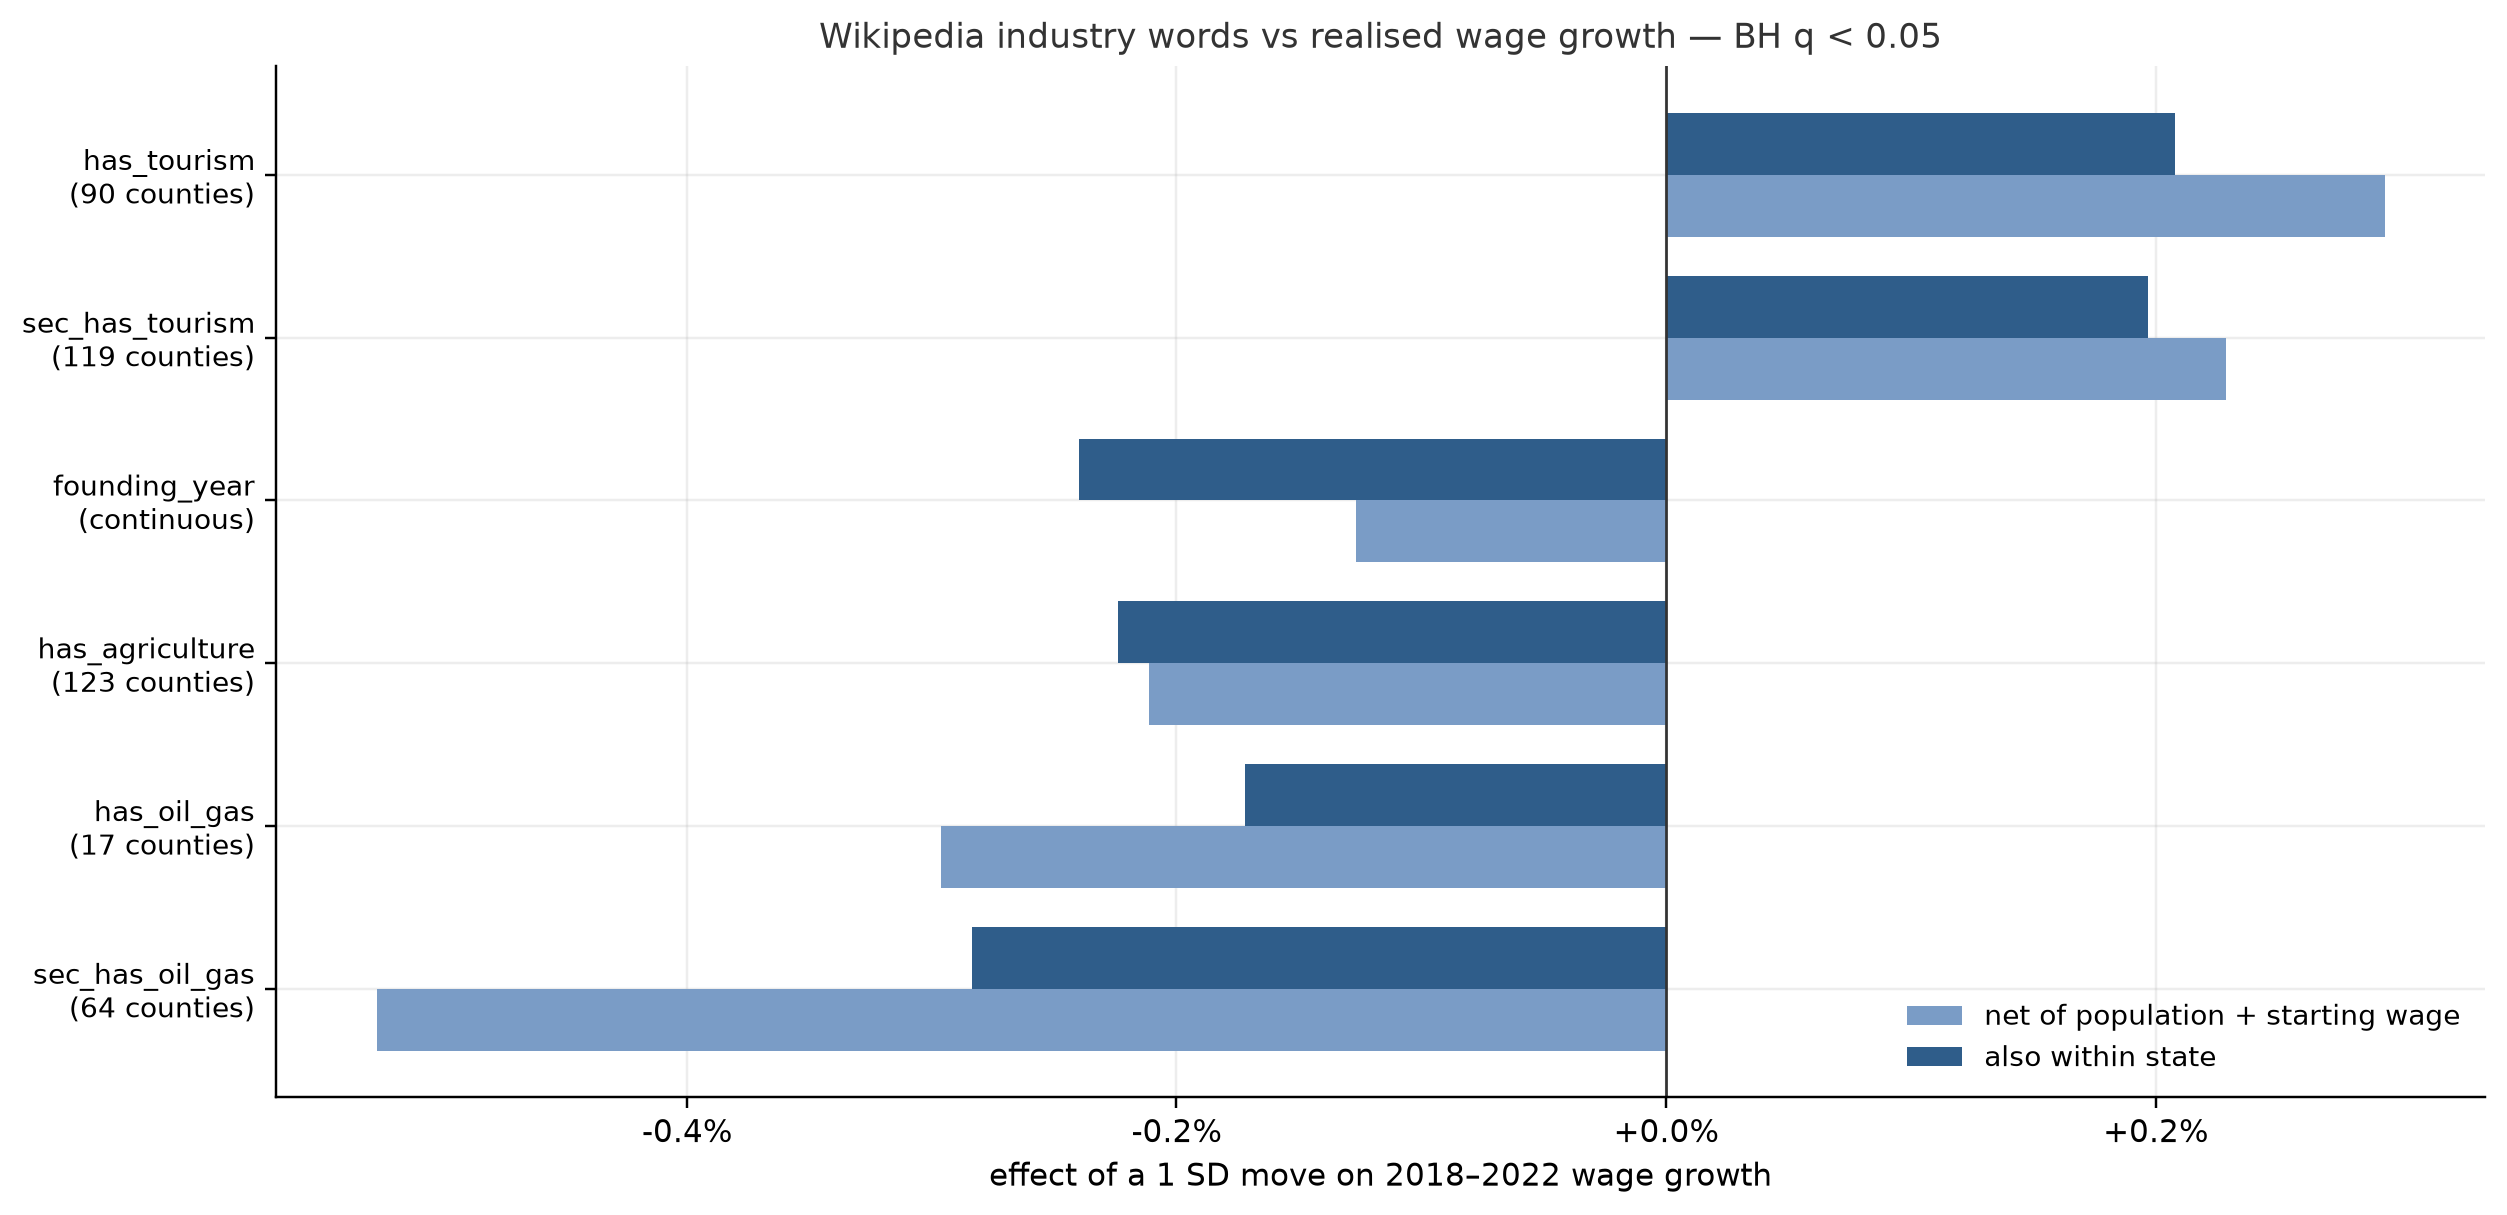

In [8]:
effect_chart(
    GROWTH,
    ("net of population + starting wage", "also within state",
     f"effect of a 1 SD move on {START_YEAR}–{END_YEAR} wage growth"),
    f"Wikipedia industry words vs realised wage growth — BH q < {stats['q_threshold']}",
    formatter=lambda v, _: f"{v * 100:+.1f}%",
)

---

## What this adds

- **Against a non-Census target, Source A's typed block predicts wage levels
  out-of-fold — and survives the lat/lon control that erased every previous
  win.** Small, but its interval clears zero.
- **The tier gradient is roughly two-thirds county size.** The tiers are a
  diagnostic, not a feature: the block is a *cost* in the stub tier.
- **Article shape is an editor artifact, and a new one for the register.**
  Section inventory, ordering and typography predict wages under random folds
  and *reverse sign* under held-out states, because which sections an article
  has is set per state by whoever templated it. §23–§24 established that the
  shape block carries county size; this adds that what it carries beyond size
  does not cross a state line. `content_length` and the lexicon block do not
  behave this way.
- **On growth, the lexicon columns behave like the industry statements they
  claim to be.** Strongest evidence yet that the extraction reads economics and
  not article size — from the one target where article size is uninformative by
  construction.

**Not established.** Growth effects are column-level and small; nothing here
shows they survive inside the full six-pillar matrix, where Source B's QCEW
location quotients already name every county's industry mix directly. That is
the next test and it is not run here.